# Regresión Lineal
P tuplas $\{x_{i1},x_{i2},...,x_{iN},z_i\}_{i=1}^P$, en donde cada $z_i$ son los resultados correctos. El modelo hace:

$z_i = a_1 x_{i1} + a_2 x_{i2} + ... + a_N x_{iN} + a_{N+1}$
Si tengo M slidas entonces seria

$\{x_{i1},...,x_{iN},z_{1i},...,z_{Mi}\}_{i=1}^P$.

$a$ es una matriz de $N+1$ por $M$.

### Inicialización

In [1]:
import numpy as np
import pandas as pd


np.set_printoptions(formatter={'float': lambda x: "{0:0.2f}".format(x)})

df = pd.read_csv('./RNA_TP1_datasets.tar/tp1_ej2_training.csv', sep=',',header=None).to_numpy()
data = df[:,:8]
z = df[:,8:]

n = len(data[0])
m = len(z[0])
p = len(data)

x_full = np.zeros((p,n+1))
x_full[:,:-1] = data
x_full[:,-1] = 1

#x[:,1] = np.sqrt(x[:,1])
#x[:,3] = np.sqrt(x[:,3])
#x[:,6] = np.sqrt(x[:,6])

x = x_full / x_full.max(axis=0)
w = np.random.normal( 0, 0.1, (n+1,m))


### Entrenamiento

In [2]:
lr_a = 0.0001
lr_b = 0.0005
decay = 0.001

momentum = True
E = []

e = 1
t = 0
epochs = 12000
out_modulus = epochs/8
lr = lr_a

y = np.dot( x, w)
d = z-y
dw = lr*np.dot( x.T, d)
    
while (e>0.01) and (t<epochs):
    y = np.dot( x, w)
    d = z-y
    dw_old = dw
    dw_new = lr*np.dot( x.T, d)
    dw = dw_new + (1-decay)*dw_old
    if not momentum:
        dw = dw_new
    if t == epochs/2:
        lr = lr_b = 0.0005
    w += dw
    e = np.mean( np.square( d))
    E.append( e)
    t += 1
    if t%out_modulus==0:
        print( t, e)
   

1500 80.19320209780635
3000 28.234545780516477
4500 20.28961096697206
6000 10.383398056967073
7500 10.554417759002288
9000 10.301544623756756
10500 10.248900208410392
12000 10.244981006723748


### Resultados

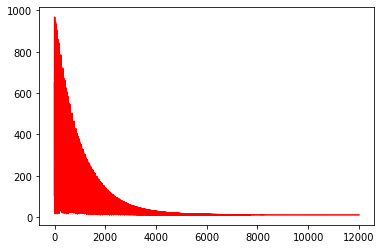

y: [9.18 13.44], z: [10.75 14.27], dif: [-1.57 -0.83]
y: [32.69 34.93], z: [38.98 45.97], dif: [-6.29 -11.04]
y: [10.94 14.47], z: [11.69 13.72], dif: [-0.75 0.75]
y: [19.24 19.82], z: [16.54 16.88], dif: [2.70 2.94]
y: [31.11 33.64], z: [24.77 29.79], dif: [6.34 3.85]


In [3]:
     
from matplotlib import pyplot as mpl

mpl.plot(E,'r')
mpl.show()


for i in range(5):
    out = np.dot(x[i],w)
    dif = out - z[i]
    print("y: " + str(out)+ ", z: " +str(z[i]) + ", dif: " + str(dif))


### Notas

1) El error converge a un valor cercano a 10.24 en vez de 0. No sabemos la causa de esto. Es improbable que se deba a un minimo local, ya que los valores de w son inicializados al azar. Lo mas probable es que se deba a limitaciones del modelo. Por ejemplo, es probable que la relación entre las variables y los valores objetivo no sea lineal. De ser así, deberiamos ver un resultado similar al utilizar una red unicapa, y una mejora al utilizar una multi-capa.

Se intentó utilizar la raiz de los datos que se diferencian cuadraticamente entre ejemplos, como las areas. Esto resultó en un error mayor.

2) Con learning rates razonables, el modelo diverge en ausencia de normalización, por eso ese decidió utilizarla.

3) Se implementó un learning rate en dos etapas. El primero para la primera mitad de las epocas. El segundo, más grande, para las ultimas. Esto obviamente funciona mejor. El defecto es que la diferencia entre el learning rate que no diverge en la primera mitad y en la segunda no es tan grande, para este caso resultó ser cinco veces mayor. Dicho esto, el cambio de velocidad de cambio entre errores de iteraciones sucesivas fue, en muchos casos, ordenes de magnitud mayor que el cociente entre learning rates.

4) Se experimentó con la utilización de momento en el modelo. Esto es, utilizar la suma de todos los $d_w$ calculados, pero disminuir su magnitud en cada iteracion por un factor fijo. A pesar causar oscilaciones en el error, resultó optimo en 0.001. Esto aumentó significativamente la velocidad de convergencia.